In [1]:
import torch
import torch.nn.functional as f
from torchsummary import summary

In [2]:
import torchvision.models as model
vgg_model = model.vgg16(pretrained=True)
vgg_model

d:\machine-learning\computer vision\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\machine-learning\computer vision\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [3]:
# Pool3
# Pool 4
# Final Output

In [4]:
summary(vgg_model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [5]:
import torch.nn as nn 

In [6]:
class FCN8(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        vgg_model = model.vgg16(pretrained=True)
        self.features = vgg_model.features

        # extract intermediate feature maps
        self.pool3 = self.features[:17]  
        self.pool4 = self.features[:24]
        self.pool5 = self.features

        # 1*1 convolutions to convert to class score
        self.conv1x1_3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.conv1x1_4 = nn.Conv2d(512, num_classes, kernel_size=1)
        self.conv1x1_5 = nn.Conv2d(512, num_classes, kernel_size=1)

        # Apply upsampling
        self.upsampl32 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1) 
        self.upsampl16 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1)
        self.upsampl8 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=16, stride=8, padding=4)

    def forward(self, x):
        pool3_out = self.pool3(x)
        pool4_out = self.pool4(x)
        pool5_out = self.pool5(x)

        pool3_out = self.conv1x1_3(pool3_out)
        pool4_out = self.conv1x1_4(pool4_out)
        pool5_out = self.conv1x1_5(pool5_out)

        x = self.upsampl32(pool5_out) + pool4_out
        x = self.upsampl16(x) + pool3_out
        x = self.upsampl8(x)

        return x 


In [26]:
fcn_nodel = FCN8(num_classes=100)
dummy_input = torch.randn(1, 3, 224, 224)
output = fcn_nodel(dummy_input)
print(output.shape)

torch.Size([1, 100, 224, 224])


In [27]:
fcn_nodel = FCN8(num_classes=10)
dummy_input = torch.randn(1, 3, 224, 224)
output = fcn_nodel(dummy_input)
print(output.shape)

torch.Size([1, 10, 224, 224])


In [7]:
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
num_classes = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FCN8(num_classes=num_classes).to(device)
model.eval()

d:\machine-learning\computer vision\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\machine-learning\computer vision\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FCN8(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

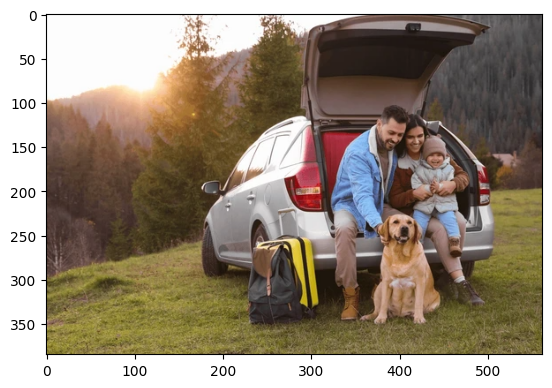

In [9]:
image = "../dataset/seg.png"
image = Image.open(image).convert("RGB")
plt.imshow(image)

In [10]:
import torchvision.transforms as transforms 

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

input_tensor = transform(image).unsqueeze(0).to(device)

In [12]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

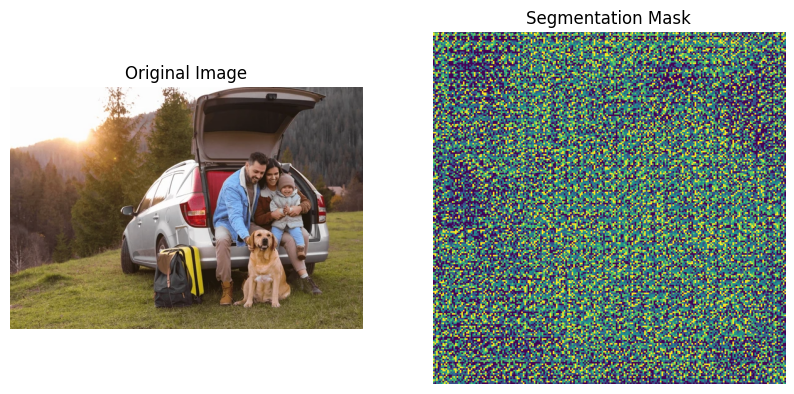

In [16]:
# Forward pass
with torch.no_grad():
    output = model(input_tensor)  # shape: (1, num_classes, H, W)
    pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

# Visualize segmentation mask
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentation Mask")
plt.imshow(pred_mask)
plt.axis("off")
plt.show()